# Social Data Analysis: Generalities, Complex Networks and Node-Centric Metrics

In this practical work, we will first check  :
 - if a network satisfies the 3 constraints to be considered as a complex network and 
 - then, we will determine how important nodes are within this network. 

The library we will use for handling networks is networkx

## First, let's install the expecting libraries 
(not necessary if you are certain these libs are installed on your system)

In [21]:
%pip -q install --upgrade pip
%pip -q install pandas
%pip -q install networkx
%pip -q install ipython-cypher
%pip -q install py2neo
%pip -q install neo4j
%pip -q install matplotlib
%pip -q install neo4j-viz
%pip -q install graphdatascience

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Second, let's import the useful packages
You can avoid the first line if you are not using a Jupyter notebook. This line enables the visualization to be displayed in the notebook.

In [3]:
%matplotlib inline

import networkx as nx
from networkx.algorithms import community 
from networkx.algorithms.community import * 
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import random

#### **Good, if you have not encounter any problems, we can start working now!**

#### First download the dataset (on Moodle)

In [4]:
# Obviously, you must replace the path below by the appropriate path
workspace = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_FLLGRF/" 
path = "TP3/Clean_Database/database/Everything/"
file1 = "database_formated_for_NetworkX.graphml"
pathData = workspace + path + file1

In [5]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

# Check the complex network properties
## Long-tail distribution

### Plot the degree distribution of the graph
  1. Calculate and store the degree of each node     
    - The number of node'neighbours represents its degree $d_{v}= |N(v)|$       
    - in-degree dv in and out-degree dvout :
      - incoming neighbours $N_{in}(v) d_v^{in}$ : number of edges pointing to node v
      - outcoming neighbours $N_{out}(v) d_v^{out}$ : number of edges pointing away from node v    
2. Convert the result (a dict) into a Pandas object, a Series          

In [5]:
def make_dataframe(GD):
#df1 = pd.DataFrame(GD, columns=['ID', 'Node name']) 
    df2 = pd.DataFrame(GD.degree(), columns=['ID', 'degree neighb']) 
  #  df2 = pd.DataFrame(GD.number_of_nodes(), columns=['ID', 'number nodes']) 
    df3 = pd.DataFrame(GD.in_degree() , columns=['ID', 'degree in']) 
    df4 = pd.DataFrame(GD.out_degree() , columns=['ID', 'degree out']) 
    df5 = pd.DataFrame(GD.in_degree(weight = "weight") , columns=['ID', 'weight in']) 
    df6 = pd.DataFrame(GD.out_degree(weight = "weight") , columns=['ID', 'weight out']) 
    # Combinez les listes de tuples en utilisant zip
    df = pd.merge(df2, df3, on='ID')
    df = pd.merge(df, df4, on='ID')
    df = pd.merge(df, df5, on='ID')
    df = pd.merge(df, df6, on='ID')
    # Trier par le degré total (ou une autre colonne)
    df = df.sort_values(by='degree neighb', ascending=False)
    
    # Extraire les propriétés des nœuds
    node_properties = []
    for node, data in GD.nodes(data=True):
        properties = {"ID": node}  # Inclure l'identifiant du nœud
        properties.update(data)   # Ajouter toutes les propriétés du nœud
        node_properties.append(properties)

    # Créer un DataFrame à partir des propriétés des nœuds
    properties_df = pd.DataFrame(node_properties)

    # Fusionner avec le DataFrame des degrés
    df = pd.merge(df, properties_df, on='ID')

    filtered_df = df[df['labels'] == ':Event']
    # Conserver uniquement les colonnes pertinentes
    filtered_df = filtered_df[['ID', 'id', 'trecisid', 'eventType','degree in',]]   

    # Trier par `eventType`
    sorted_df = filtered_df.sort_values(by='eventType')

    return sorted_df

In [6]:
make_dataframe(G).head(5).style

,ID,id,trecisid,eventType,degree in
12,n20,parisAttacks2015,TRECIS-CTIT-H-021,bombing,4080
69,n5,westTexasExplosion2013,TRECIS-CTIT-H-006,bombing,368
40,n11,bostonBombings2013,TRECIS-CTIT-H-012,bombing,1069
0,n18,nepalEarthquake2015,TRECIS-CTIT-H-019,earthquake,11269
108,n7,italyEarthquakes2012,TRECIS-CTIT-H-008,earthquake,205


In [7]:
# Fonction de base pour afficher un sous-graphe
def display_subgraph(G, node_size=5, iterations=10, k=0.5, deg=100, ax=None):
    # Filtrer les nœuds avec un degré supérieur à `deg`
    filtered_nodes = [node for node, degree in G.degree() if degree > deg]
    subgraph = G.subgraph(filtered_nodes)

    # Calculer la disposition des nœuds
    pos = nx.spring_layout(subgraph, k=k, iterations=iterations)

    # Créer un dictionnaire de labels basé sur l'attribut 'id'
    labels = {node: data['id'] for node, data in subgraph.nodes(data=True) if 'id' in data}

    # Afficher le sous-graphe
    ax.set_facecolor('white')
    nx.draw(subgraph, pos, ax=ax, labels=labels, node_size=node_size,
            node_color='blue', linewidths=0.1, with_labels=False)
    
    # Ajouter les labels des nœuds
    for node, (x, y) in pos.items():
        if node in labels:
            ax.text(x, y + 0.04, s=labels[node], fontsize=8, ha='center', color='blue')

In [8]:
# Fonction pour afficher plusieurs sous-graphes
def display_multiple_subgraphs(graph_list, node_size=5, iterations=10, k=0.5):
    n = len(graph_list)  # Nombre total de sous-graphes
    cols = 2  # Nombre de colonnes (2 graphiques par ligne)
    rows = (n + cols - 1) // cols  # Calculer le nombre de lignes nécessaires

    # Créer une figure avec plusieurs sous-graphiques
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour itérer facilement

    # Tracer chaque sous-graphe
    for i, (weightDeg, G, eventtype) in enumerate(graph_list):
        display_subgraph(G, node_size=node_size, iterations=iterations, k=k, deg=int(weightDeg), ax=axes[i])
        axes[i].set_title(eventtype)

    # Supprimer les axes inutilisés si le nombre total de graphes est inférieur à `rows * cols`
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Ajuster l'espacement entre les graphiques
    plt.tight_layout()
    plt.show()

In [9]:
def build_displayEventypeFamily(eventType= 'bombing'):
    # Vérifier si le type d'évènement existe dans le graphe
    filtered_nodes = [node for node, data in G.nodes(data=True) if data.get('eventType') == eventType]

    neighbors=[]
    for target_node in filtered_nodes:
        # Extraire les voisins directs (entrants et sortants)
        neighbors += list(G.neighbors(target_node))
        neighbors += list(G.predecessors(target_node))

    # Inclure le nœud lui-même et ses voisins dans le sous-graphe
    related_nodes = set (filtered_nodes + neighbors)
    G.remove_edges_from(nx.selfloop_edges(G))
    subgraph = G.subgraph(related_nodes)
    return subgraph

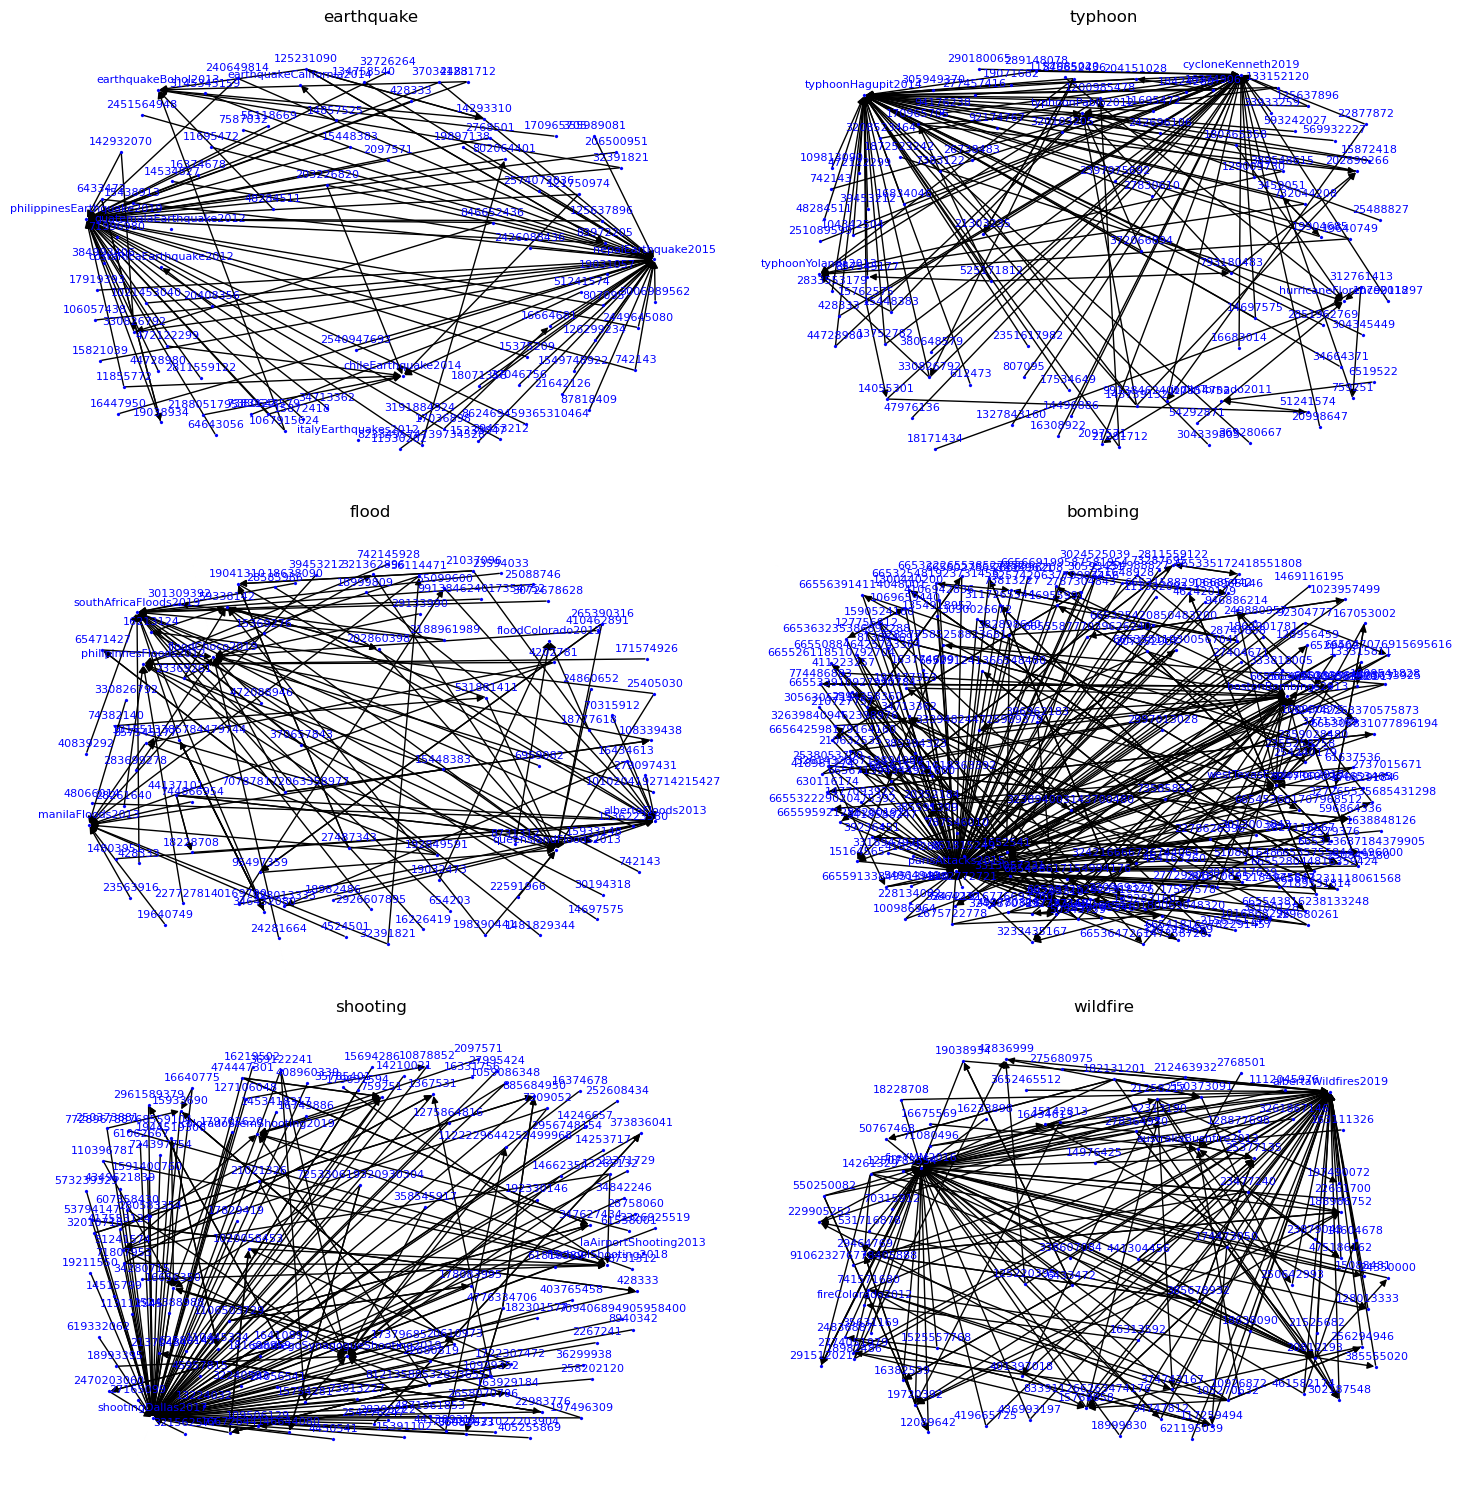

In [10]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

# Extraire tous les `eventType` uniques
event_types = {data['eventType'] for node, data in G.nodes(data=True) if 'eventType' in data}
# Convertir en liste si nécessaire
event_types = list(event_types)
weightPos = {'bombing':2, 'shooting':6, 'earthquake':7, 'typhoon':10, 'flood':8, 'wildfire':15}
graph_list = []
 
for event_type in event_types: 
    weight = weightPos.get(event_type, 1)   
    subgraph = build_displayEventypeFamily(event_type)
    graph_list.append((weight, subgraph, event_type))
# Afficher les sous-graphes avec des titres correspondant aux eventTypes

display_multiple_subgraphs(graph_list)

__Ce schéma illustre clairement comment les différents éléments d'un graphe Twitter interagissent. Il peut être utilisé pour explorer diverses dimensions, comme l'engagement social, la diffusion de contenu, et l'analyse thématique. Si vous avez besoin d'une exploration plus détaillée ou d'autres visualisations, cela peut être approfondi avec des outils comme Neo4j__

In [4]:
import os
import json
from neo4j import GraphDatabase

In [3]:
# Chemin du répertoire contenant les fichiers JSON
path = "/Users/asriel/Library/Application Support/Neo4j Desktop/Application/relate-data/dbmss/dbms-2b32bab4-6f69-41b9-b387-635d89a4b98c/import/"
os.chdir(path)

# Répertoires contenant les fichiers JSON
nodes_directory = "Nodes"
relationships_directory = "Relationships"

In [4]:
def delete_all_nodes(driver):
    """Supprime tous les nœuds et leurs relations dans la base de données."""
    with driver.session() as session:
        query = "MATCH (n) DETACH DELETE n"
        session.run(query)
        print("Tous les nœuds et leurs relations ont été supprimés.")        

In [5]:
def load_json_file(file_path):
    """Charge un fichier JSON et retourne les données sous forme de liste."""
    # print(f'load_json_file : {file_path}')
    with open(file_path, 'r', encoding='utf-8') as file:
        data = []
        for line in file:
            try:
                data.append(json.loads(line.strip()))
            except json.JSONDecodeError as e:
                print(f"Erreur lors de la lecture de la ligne : {e}")
        return data

In [7]:
def create_node(driver, data):
    """Crée des nœuds dans la base de données Neo4j à partir des données fournies."""
    created_nodes = []
    with driver.session() as session:
        for entry in data:
            # Extract properties
            node_data = entry['n']
            properties = node_data['properties']
            external_id = node_data['id']  # Cet id est celui de niveau supérieur dans le JSON
            properties['external_id'] = external_id  # On l'ajoute aux propriétés pour le stocker dans Neo4j
            properties = entry['n']['properties']
            labels = ":".join(entry['n']['labels'])
            # Construct Cypher query
            cypher_query = f"CREATE (n:{labels} " + "{" + ", ".join([f"{key}: {json.dumps(value)}" 
                             for key, value in properties.items()]) + "})"
            try:
                # Exécuter la requête avec les propriétés dynamiques
                result = session.run(cypher_query)

                # Ajouter les nœuds créés à la liste
                for record in result:
                    created_nodes.append(record['n'])
            except Exception as e:
                # Gérer les erreurs potentielles
                print(f"Erreur lors de la création du nœud : {e}")
    return created_nodes            

In [8]:
def add_uuid_to_all_nodes(driver):
    """Ajoute un UUID à tous les nœuds qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""MATCH (n) WHERE n.uniqueId IS NULL SET n.uniqueId = randomUUID()""")

In [9]:
def create_nodes(driver):
    """Crée des nœuds et des relations à partir des fichiers JSON dans les répertoires spécifiés."""
    # Supprimer tous les nœuds existants
    #delete_all_nodes(driver)

    # Liste des fichiers JSON dans les répertoires
    node_files = [f for f in os.listdir(nodes_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Nodes"
    for file_name in node_files:
        file_path = os.path.join(nodes_directory, file_name)
        data = load_json_file(file_path)
        # Assurer que tous les éléments possèdent les attributs requis
        #complete_data = ensure_attributes(data, required_attributes, default_values)
        # Créer les nœuds
        created_nodes = create_node(driver, data)
        print(f"Fichier : {file_name} -> Nœuds créés avec toutes les propriétés.")
        
    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_nodes(driver)

In [10]:
def delete_all_relationShip(driver):
    """Supprime toutes les relations de la base de données."""
    with driver.session() as session:
        query = "MATCH ()-[r]->() DELETE r"
        session.run(query)
        print("Tous les relations ont été supprimées.")

In [11]:
def create_relationship(driver, data):
    """Crée des relations dans la base de données Neo4j à partir des données fournies."""
    with driver.session() as session:
        for entry in data:
            if 'r' in entry and entry['r'].get('type') == 'relationship':
                label = entry['r'].get('label')
                start_id = entry['r']['start'].get('id')
                start_label = entry['r']['start'].get('labels')
                end_id = entry['r']['end'].get('id')
                end_label = entry['r']['end'].get('labels')

                if start_id is None or end_id is None or label is None:
                    print(f"Erreur : Clé manquante dans l'entrée {entry}")
                    continue

                # Assurez-vous que les labels sont des chaînes de caractères
                if isinstance(start_label, list):
                    start_label = start_label[0]
                if isinstance(end_label, list):
                    end_label = end_label[0]

                # Construire dynamiquement la requête Cypher pour les relations
                query = f"""
                    MATCH (start:{start_label} {{external_id: $start_id}}), (end:{end_label} {{external_id: $end_id}})
                    CREATE (start)-[r:{label}]->(end)
                    RETURN r
                    """
                try:
                    # Exécuter la requête avec les identifiants dynamiques
                    session.run(query, start_id=start_id, end_id=end_id)
                except Exception as e:
                    print(f"Erreur lors de l'exécution de la requête : {e}")

In [12]:
def add_uuid_to_all_relationships(driver):
    """Ajoute un UUID à toutes les relations qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""
        MATCH ()-[r]->()
        WHERE r.uniqueId IS NULL
        SET r.uniqueId = randomUUID()
        """)

In [13]:
# Traiter les fichiers JSON dans le répertoire "Relationships"
def create_relationships(driver):
    
    #delete_all_relationShip(driver)
    relationship_files = [f for f in os.listdir(relationships_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Relationships"
    for file_name in relationship_files:
        file_path = os.path.join(relationships_directory, file_name)
        data = load_json_file(file_path)
        create_relationship(driver, data)
        print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_relationships(driver)

In [19]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
# Exécuter le processus de création de nœuds et de relations

file_name = 'RETWEETED.json'
file_path = path+"/"+relationships_directory+"/"+file_name
# Traiter les fichiers JSON dans le répertoire "Relationships"
data = load_json_file(file_path)
create_relationship(driver, data)
print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

# Ajouter des UUID à tous les nœuds
add_uuid_to_all_relationships(driver)
driver.close()

Fichier : RETWEETED.json -> Relations créées avec toutes les propriétés.


In [5]:
# Connexion à la base Neo4j
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
# Exécuter le processus de création de nœuds et de relations
#create_nodes(driver)
#create_relationships(driver)
# Fermer la connexion
driver.close()

### Heterogeneous graph
 __This network graph is composed of multiple types of nodes and multiple types of edges this is an heterogeous graph__

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=400/>
</p>

In [15]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
def get_labels(tx):
    result = tx.run("CALL apoc.meta.stats() YIELD labels RETURN labels")
    return result.single()["labels"]
with driver.session() as session:
    labels = session.execute_read(get_labels)
    print(labels)
driver.close()

{'Hashtag': 10441, 'User': 43141, 'Event': 34, 'PostCategory': 25, 'Tweet': 55986}


In [16]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))   
with driver.session() as session:
    result = session.run("MATCH (n) RETURN DISTINCT labels(n), keys(n)")
    for record in result:
        print(record)          
driver.close()

<Record labels(n)=['Tweet'] keys(n)=['id', 'isTruncated', 'possibly_sensitive', 'created_at', 'retweet_count', 'annotation_annotated', 'is_quote_status', 'annotation_num_judgements', 'annotation_postPriority', 'id_str', 'topic', 'favorite_count', 'text', 'uniqueId', 'external_id']>
<Record labels(n)=['Tweet'] keys(n)=['id', 'isTruncated', 'possibly_sensitive', 'created_at', 'retweet_count', 'annotation_annotated', 'is_quote_status', 'annotation_num_judgements', 'annotation_postPriority', 'id_str', 'topic', 'favorite_count', 'text', 'uniqueId', 'external_id', 'pageRank']>
<Record labels(n)=['Tweet'] keys(n)=['id', 'isTruncated', 'possibly_sensitive', 'created_at', 'retweet_count', 'annotation_annotated', 'is_quote_status', 'annotation_num_judgements', 'annotation_postPriority', 'topic', 'favorite_count', 'text', 'uniqueId', 'external_id']>
<Record labels(n)=['Event'] keys(n)=['trecisid', 'id', 'eventType', 'uniqueId', 'external_id', 'eventTypeId']>
<Record labels(n)=['Event'] keys(n)=['

In [17]:
# Donner le nombre de relations par type ; 
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("MATCH ()-[r]->() RETURN type(r) AS relationType, COUNT(r) AS occurrences ORDER BY occurrences DESC")
     
    for record in result:
        print(f"Nombre : {record['occurrences']} de noeuds par type : {record['relationType']}")          
driver.close()

Nombre : 96566 de noeuds par type : HAS_CATEGORY
Nombre : 55986 de noeuds par type : POSTED
Nombre : 55414 de noeuds par type : HAS_HASHTAG
Nombre : 36668 de noeuds par type : IS_ABOUT
Nombre : 31134 de noeuds par type : TALKS_ABOUT
Nombre : 20894 de noeuds par type : MENTIONS
Nombre : 7578 de noeuds par type : RETWEETED
Nombre : 6296 de noeuds par type : RETWEETS
Nombre : 2479 de noeuds par type : REPLY_TO
Nombre : 1840 de noeuds par type : REPLIED_TO


In [18]:
# Donner le nombre de relations par type ; 
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("MATCH (n)-[r]->() RETURN n, COUNT(r) AS occurrences, r AS name ORDER BY occurrences DESC lIMIT 5") 
    for record in result:
        print(f"Nombre : {record['occurrences']} de noeuds par type : {record['name']}")          
driver.close()

Nombre : 1 de noeuds par type : <Relationship element_id='5:4da88401-a5f5-4fc8-9db2-077d56e88509:1152928101676613632' nodes=(<Node element_id='4:4da88401-a5f5-4fc8-9db2-077d56e88509:0' labels=frozenset({'Tweet'}) properties={'isTruncated': False, 'possibly_sensitive': True, 'created_at': '2012-06-12T00:00Z', 'external_id': '643', 'retweet_count': 0, 'annotation_annotated': True, 'is_quote_status': False, 'annotation_num_judgements': 1, 'annotation_postPriority': 'Medium', 'id_str': '212364712506163201', 'topic': 'TRECIS-CTIT-H-001', 'favorite_count': 0, 'id': 212364712506163201, 'text': '62 year old linda stedman killed in #highparkfire', 'uniqueId': 'a5deb762-5c84-4c56-956f-f0dd082ae308'}>, <Node element_id='4:4da88401-a5f5-4fc8-9db2-077d56e88509:109563' labels=frozenset() properties={}>) type='HAS_CATEGORY' properties={'uniqueId': '77979f7c-b902-4b57-8ab1-c320969dec55'}>
Nombre : 1 de noeuds par type : <Relationship element_id='5:4da88401-a5f5-4fc8-9db2-077d56e88509:11529303006998691

In [19]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))   
with driver.session() as session:
    result = session.run("CALL db.relationshipTypes()")
    for record in result:
        print(record)          
driver.close()

<Record relationshipType='MENTIONS'>
<Record relationshipType='POSTED'>
<Record relationshipType='REPLY_TO'>
<Record relationshipType='HAS_HASHTAG'>
<Record relationshipType='TALKS_ABOUT'>
<Record relationshipType='REPLIED_TO'>
<Record relationshipType='HAS_CATEGORY'>
<Record relationshipType='RETWEETS'>
<Record relationshipType='IS_ABOUT'>
<Record relationshipType='RETWEETED'>


In [20]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))   
with driver.session() as session:
    result = session.run("""
            MATCH (e:Event)<-[:IS_ABOUT]-(t:Tweet)
            RETURN e.eventType AS Type, COUNT(t) AS tweetCount
            ORDER BY tweetCount DESC
                        """)
    for record in result:
        print(f"{record.value('Type')} : {record.value('tweetCount')}")          
driver.close()

earthquake : 9380
typhoon : 8913
wildfire : 5778
shooting : 5559
flood : 4255
bombing : 2783


In [21]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
def get_labels(tx):
    result = tx.run("CALL apoc.meta.stats() YIELD labels RETURN labels")
    return result.single()["labels"]
with driver.session() as session:
    labels = session.execute_read(get_labels)
    for key, value in labels.items():
        print(f"Node label: {key} having {value} values")
driver.close()

Node label: Hashtag having 10441 values
Node label: User having 43141 values
Node label: Event having 34 values
Node label: PostCategory having 25 values
Node label: Tweet having 55986 values


In [22]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("""
                MATCH ()-[r]->() RETURN type(r) AS relationType, COUNT(r) AS occurrences ORDER BY occurrences DESC                     
                        """)
    for record in result:
        print(f" Relation {record['relationType']} owns {record['occurrences']} occurences ")
driver.close()

 Relation HAS_CATEGORY owns 96566 occurences 
 Relation POSTED owns 55986 occurences 
 Relation HAS_HASHTAG owns 55414 occurences 
 Relation IS_ABOUT owns 36668 occurences 
 Relation TALKS_ABOUT owns 31134 occurences 
 Relation MENTIONS owns 20894 occurences 
 Relation RETWEETED owns 7578 occurences 
 Relation RETWEETS owns 6296 occurences 
 Relation REPLY_TO owns 2479 occurences 
 Relation REPLIED_TO owns 1840 occurences 


In [23]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
def get_itemNumber(tx):
    result = tx.run("""
        CALL apoc.cypher.run(
        "MATCH (e:Event)<-[:IS_ABOUT]-(t:Tweet)
        RETURN e.eventType AS eventType, COUNT(t) AS tweetCount", null)
        YIELD value
        RETURN value.eventType, value.tweetCount
        ORDER BY value.tweetCount DESC
    """) 
    # Convert the result to a list to consume it within the transaction
    return list(result)
with driver.session() as session:
    labels = session.execute_read(get_itemNumber)
    for record in labels:
        print(f"The {record['value.eventType']} counts {record['value.tweetCount']} tweets occurences")
driver.close()

The earthquake counts 9380 tweets occurences
The typhoon counts 8913 tweets occurences
The wildfire counts 5778 tweets occurences
The shooting counts 5559 tweets occurences
The flood counts 4255 tweets occurences
The bombing counts 2783 tweets occurences


In [24]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))   
with driver.session() as session:
    result = session.run("""
            MATCH (e:Event)<-[:IS_ABOUT]-(t:Tweet)
            WITH e, COUNT(t) AS tweetCount,
            CASE
                WHEN e.id =~ '.*(\d{4})$' THEN toInteger(substring(e.id, size(e.id)-4))
                ELSE null
            END AS year
            RETURN e.eventType AS eventType,e.id AS event_id, year, tweetCount
            ORDER BY year ASC LIMIT 5
                        """)
    for record in result:
        print(f"The {record.value('year')} {record.value('eventType')} for event {record.value('event_id')} counts {record.value('tweetCount')} dated tweets ")          
driver.close()

The 2011 typhoon for event joplinTornado2011 counts 96 dated tweets 
The 2012 wildfire for event fireColorado2012 counts 263 dated tweets 
The 2012 earthquake for event costaRicaEarthquake2012 counts 247 dated tweets 
The 2012 typhoon for event typhoonPablo2012 counts 244 dated tweets 
The 2012 earthquake for event guatemalaEarthquake2012 counts 154 dated tweets 


In [25]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("""
                MATCH (e:Event)
                MATCH (t:Tweet {topic: e.trecisid})
                RETURN e.eventType AS eventType, e.id AS event_id, COUNT(t) AS tweetCount
                ORDER BY tweetCount ASC LIMIT 5
                        """)
    for record in result:
            print(f"The {record.value('eventType')} for event {record.value('event_id')} counts {record.value('tweetCount')} tweets ")          
driver.close()

The typhoon for event joplinTornado2011 counts 123 tweets 
The earthquake for event earthquakeCalifornia2014 counts 138 tweets 
The earthquake for event italyEarthquakes2012 counts 154 tweets 
The earthquake for event guatemalaEarthquake2012 counts 247 tweets 
The earthquake for event chileEarthquake2014 counts 311 tweets 


In [26]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("""
            MATCH (e:Event {eventType: 'wildfire'})
            MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
            RETURN e.id AS eventId, collect(DISTINCT u.id) AS userIds
            ORDER BY eventId LIMIT 5           
                        """)
    for record in result:
        print(f"{record['eventId']}:\n{record['userIds']}")
driver.close()

albertaWildfires2019:
[122387909, 16342817, 19042993, 73452506, 300388340, 16038877, 329135472, 28585986, 21037096, 905218015, 44137101, 18228708, 221814012, 18999830, 289998339, 16063888, 419665725, 18982486, 116502194, 52281549, 15769858, 550250082, 14803951, 212463932, 553862377, 16434613, 128013333, 279097431, 30644410, 71080496, 2164169846, 21258217, 36711678, 142614009, 16973333, 18638090, 6433472, 168757829, 190738551, 16219502, 16044997, 3250947120, 200838452, 80048640, 19240249, 313145240, 461582174, 23477240, 117259494, 1250785554, 436019839, 20812193, 22661700, 174473050, 125220395, 2810630287, 373543624, 16856411, 69087384, 164762035, 308859876, 78749005, 251926250, 19743540, 596201340, 436993197, 3873984133, 22454160, 424764913, 74672082, 20165785, 15088481, 4108188865, 105270632, 20332787, 70553160, 272002337, 242873777, 522208363, 237574507, 35162290, 23624320, 3606823994, 90949148, 39570442, 21214977, 2911026834, 17604684, 608835608, 83898873, 511021343, 3360725114, 253

In [27]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("""
            MATCH (e:Event {eventType: 'wildfire'})
            MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
            WITH u, collect(DISTINCT e.id) AS eventIds
            WHERE size(eventIds) > 1
            RETURN u.id AS userId, u.name AS userName, eventIds
            ORDER BY userId LIMIT 5                       
                        """)
    for record in result:
        print(f"The stakeholder {record['userId']} named {record['userName']} have exchanged during {record['eventIds']} events")
driver.close()

The stakeholder 428333 named CNN Breaking News have exchanged during ['fireColorado2012', 'australiaBushfire2013'] events
The stakeholder 759251 named CNN have exchanged during ['fireColorado2012', 'australiaBushfire2013'] events
The stakeholder 6433472 named CBC News have exchanged during ['fireYMM2016', 'albertaWildfires2019'] events
The stakeholder 15088481 named Mike Hudema have exchanged during ['fireYMM2016', 'albertaWildfires2019'] events
The stakeholder 15250661 named news.com.au have exchanged during ['fireColorado2012', 'australiaBushfire2013'] events


## Analyse de graphe
__Les attributs de tweet peuvent être interprétés comme suit pour fournir des insights significatifs.__ 

:::

- __isTruncated (booléen) :__ Indique si le texte du tweet est tronqué. Utile pour identifier les tweets nécessitant de récupérer le texte complet pour l’analyse sémantique.
 
- __possibly_sensitive (booléen) :__ Indique si le contenu du tweet est potentiellement sensible.
Permet de pour filtrer ou marquer les tweets nécessitant une attention particulière pour la modération ou la diffusion de contenu controversé.   

- __created_at (date) :__ La date et l'heure de création, permet d'analyser la temporalité comme l'identification des pics d'activité ou les tendances liées à un événement spécifique.

- __retweet_count (nombre) :__ Le nombre de fois qu'un tweet a été retweeté est un indicateur de popularité ou d'engagement, utile pour identifier les tweets influents. Peut être utilisé pour identifier les nœuds les plus influents dans le graphe.

- __annotation_annotated (booléen) :__ Indique si le tweet a été annoté manuellement. Peut être utilisé pour distinguer les tweets qui ont été examinés ou catégorisés par des humains.

- __is_quote_status (booléen) :__ Indique si le tweet est une citation d'un autre tweet. Utile pour analyser les interactions et les conversations entre les utilisateurs.

- __annotation_annotated et annotation_num_judgements :__ Indiquent si un tweet a été annoté et combien de jugements ont été effectués. Utile et pertinent dans des contextes où les tweets sont analysés manuellement ou automatiquement pour des tâches comme la classification thématique ou la détection d’émotions.

- __id_str et id (chaîne de caractères et nombre) :__ L'dentifiants uniques du tweet est utilisés pour référencer et retrouver spécifiquement ce tweet dans le graphe.

- __topic (chaîne de caractères) :__ Le sujet ou la catégorie associée au tweet, elle permet de regrouper et d'analyser les tweets par thèmes ou catégories.

- __favorite_count (nombre) :__ Nombre de fois que le tweet a été marqué comme favori est un indicateur d’engagement qui peut être combiné avec __retweet_count__ pour évaluer l’impact global d’un tweet.  
 
- __text (chaîne de caractères) :__ Le contenu textuel du tweet est essentiel pour l'analyse de contenu, l'extraction de thèmes, de sentiments, ou de mots-clés.

- __Hashtags (ex. #FortMcMurray, #ymmfire) :__ Utilisés pour identifier les sujets tendances et les discussions populaires. Peuvent être analysés pour comprendre les thèmes et les communautés d'intérêt.

:::

### Application dans un Graphe
__Dans un graphe, ces attributs peuvent être utilisés comme suit :__

:::

Les attributs comme __retweet_count__, __favorite_count__, et __possibly_sensitive__ peuvent être utilisés comme métriques pondérant les relations entre nœuds (par exemple, force d’influence entre utilisateurs).

Les dates (__created_at__) permettent une analyse temporelle des interactions dans le graphe.

Les thèmes (__topic__) et hashtags extraits du texte (__text)__ peuvent être utilisés pour créer des sous-graphes thématiques ou détecter des communautés.

 :::

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=600 large=450/>
</p>

In [ ]:
# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    # Main tasks of recommender systems (slide 16) User-Item Ratings
    result = session.run("""
            MATCH (t:Tweet)             
            MATCH (e:Event)
            MATCH (u:User)-[:POSTED]->(t:Tweet {topic: e.trecisid})-[:HAS_HASHTAG]->(h:Hashtag)
            MATCH (t)-[:HAS_CATEGORY]->(pc:PostCategory)
            WHERE e.eventType = 'wildfire' AND e.id = 'fireColorado2012'             
            RETURN u.name AS username, t.id AS tweet, t.retweet_count AS retweet_count, t.favorite_count AS favorite_count,h.id as hash_val            
            ORDER BY t.favorite_count DESC , t.retweet_count DESC LIMIT 10                
                        """)
    for record in result:
        print(f"user {record['username']} tweet {record['tweet']} retweet count {record['retweet_count']} favorite count {record['favorite_count']} hashtag {record['hash_val']}")
driver.close()

user Instagram tweet 218111943150542849 retweet count 662 favorite count 232 hashtag wildfire
user Nat'l Day of Prayer tweet 217820241605042177 retweet count 1187 favorite count 72 hashtag WaldoCanyonFire
user Anonymous tweet 218051506077831170 retweet count 434 favorite count 62 hashtag WaldoCanyonFire
user Nat'l Day of Prayer tweet 216988373649334274 retweet count 398 favorite count 43 hashtag WaldoCanyonFire
user Nat'l Day of Prayer tweet 216988373649334274 retweet count 398 favorite count 43 hashtag AMEN
user FEMA tweet 218030791236648960 retweet count 602 favorite count 31 hashtag HighParkFire
user FEMA tweet 218030791236648960 retweet count 602 favorite count 31 hashtag WaldoCanyonFire
user FEMA tweet 218030791236648960 retweet count 602 favorite count 31 hashtag FlagstaffFire
user Colorado State Univ tweet 213669424283136001 retweet count 98 favorite count 22 hashtag HighParkFire
user City of Boulder tweet 217773649116147713 retweet count 465 favorite count 19 hashtag FlagstaffF

In [29]:
from neo4j import GraphDatabase

# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))

with driver.session() as session:
    result = session.run("""
                // Supposons que vous avez déjà calculé les valeurs min et max
                WITH 100 AS max_retweet, 0 AS min_retweet, 50 AS max_favorite, 0 AS min_favorite
                MATCH (e:Event {eventType: 'wildfire', id: 'fireColorado2012'})
                MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
                WITH t, u, e,
                    (t.retweet_count - min_retweet) / (max_retweet - min_retweet) AS normalized_retweet,
                    (t.favorite_count - min_favorite) / (max_favorite - min_favorite) AS normalized_favorite
                RETURN u.name AS username, t.id AS tweet, normalized_retweet, normalized_favorite
                ORDER BY normalized_retweet DESC, normalized_favorite DESC Limit 5    
                        """)
    for record in result:
        print(f"{record['username']} {record['tweet']} : {record['normalized_retweet']} {record['normalized_favorite']}")
driver.close()

Nat'l Day of Prayer 217820241605042177 : 11 1
BoDogg ][ ][ ][% 217979509817872384 : 11 0
Laura Pauls 220294094537244673 : 11 0
ColoradoSpringsAce 217844511932555264 : 11 0
Ky 217848760800260097 : 11 0


### __The typical tasks of traditional recommendation__
__Calcul de la Moyenne et de l'Écart-Type__ : 
- La première partie de la requête calcule la moyenne et l'écart-type pour retweet_count et favorite_count.     

__Normalisation z-score__ : 
- Le z-score est une mesure statistique qui décrit la position d'une donnée par rapport à la moyenne de l'ensemble de données, exprimée en unités d'écart-type. Les attributs sont normalisés en utilisant la formule z-score, qui ajuste les valeurs en fonction de la moyenne et de l'écart-type.  

__La formule du z-score est__ :
 $\Large z=\frac{\sigma}{(X−\mu)}$

Les valeurs négatives dans le contexte du __z-score__ sont normales et fournissent des informations précieuses sur la performance relative des tweets par rapport à la moyenne. Elles permettent de mieux comprendre la distribution de l'engagement et d'identifier les tweets qui se distinguent, que ce soit positivement ou négativement. 

In [30]:
from neo4j import GraphDatabase

# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
with driver.session() as session:
    result = session.run("""             
            // Calculer la moyenne et l'écart-type
                MATCH (t:Tweet)
                WITH   avg(t.retweet_count) AS avg_retweet, stdev(t.retweet_count) AS stddev_retweet,
                       avg(t.favorite_count) AS avg_favorite, stdev(t.favorite_count) AS stddev_favorite  
                MATCH  (e:Event {eventType: 'wildfire', id: 'fireColorado2012'})                     
                MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
                WITH t, u, e,
                    (t.retweet_count - avg_retweet) / stddev_retweet AS z_retweet,
                    (t.favorite_count - avg_favorite) / stddev_favorite AS z_favorite
                RETURN u.id AS userid, t.id AS tweet, z_retweet, z_favorite
                ORDER BY z_retweet DESC, z_favorite DESC LIMIT 5
                        """)
    for record in result:
        print(f"userid: {record['userid']} tweet: {record['tweet']} retweet: {record['z_retweet']} favorite: {record['z_favorite']}")
driver.close()

userid: 63174700 tweet: 217820241605042177 retweet: 0.26438833720595567 favorite: -0.00796395228698294
userid: 332076821 tweet: 220294094537244673 retweet: 0.26438833720595567 favorite: -0.01642537687318724
userid: 471543032 tweet: 217844511932555264 retweet: 0.26438833720595567 favorite: -0.01642537687318724
userid: 35937105 tweet: 217848760800260097 retweet: 0.26438833720595567 favorite: -0.01642537687318724
userid: 588333421 tweet: 217979509817872384 retweet: 0.26438833720595567 favorite: -0.01642537687318724


In [31]:
from neo4j import GraphDatabase

# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))

with driver.session() as session:
    result = session.run("""
                MATCH (t:Tweet)
                RETURN max(t.retweet_count) AS max_retweet, min(t.retweet_count) AS min_retweet,
                max(t.favorite_count) AS max_favorite, min(t.favorite_count) AS min_favorite     
                        """)
    for record in result:
        print(f"max_favorite : {record['max_favorite']} min_favorite {record['min_favorite']} : max_retweet  {record['max_retweet']} min_retweet {record['min_retweet']}")
driver.close()

max_favorite : 1676300 min_favorite 0 : max_retweet  568369 min_retweet 0


__Precision:__  mesure la proportion des vrais positifs parmi les éléments identifiés comme positifs par le modèle.

 $$ \text{Précision} = \frac{  \text{Vrais Positifs (TP)}}{ \text{Vrais Positifs (TP) + Faux Positifs (FP)}}$$

__Recall:__ mesure la proportion des vrais positifs parmi tous les éléments réellement positifs.

 $$ \text{Recall} = \frac{  \text{Vrais Positifs (TP)}}{ \text{Vrais Positifs (TP) + Faux Négatifs (FP)}}$$



<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=400/>
</p>

#### __Préparation et Projection du Graphe__     
__La première étape consiste à préparer et charger le graphe en mémoire de Neo4j__

:::
1.__Projection du graphe:__ Utilisation de __gds.graph.project__ et __gds.graph.project.cypher__ pour créer une vue en mémoire optimisée du graphe.  

2.__Filtrage optionnel:__ Application de __gds.graph.filter__ pour isoler des sous-graphes pertinents à l'analyse.

3.__Échantillonnage si nécessaire:__  Utilisation de __gds.graph.sample.cnarw__ ou __gds.graph.sample.rwr__ pour créer des échantillons représentatifs de grands graphes.

:::

In [ ]:
from neo4j import GraphDatabase
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))

with driver.session() as session:
    result = session.run("""SHOW PROCEDURES yield name, description, signature """)
    for record in result:
        data = [dict(record) for record in result]

# Créer un DataFrame à partir des résultats
df = pd.DataFrame(data)
# Fermeture du driver Neo4j
driver.close()

# Retirer la colonne 'extraColumn'
df = df.drop(columns=['signature'])
# Appliquer un style pour justifier le texte à gauche
df

,name,description
0,apoc.algo.aStarConfig,Runs the A* search algorithm to find the optim...
1,apoc.algo.allSimplePaths,Runs a search algorithm to find all of the sim...
2,apoc.algo.cover,Returns all `RELATIONSHIP` values connecting t...
3,apoc.algo.dijkstra,Runs Dijkstra's algorithm using the given `REL...
4,apoc.coll.elements,Deconstructs a `LIST<ANY>` into identifiers in...
...,...,...
556,gds.wcc.stream.estimate,Returns an estimation of the memory consumptio...
557,gds.wcc.write,The WCC algorithm finds sets of connected node...
558,gds.wcc.write.estimate,Returns an estimation of the memory consumptio...
559,tx.getMetaData,Provides attached transaction metadata.


### Opérations pour l'Analyse de Graphes dans Neo4j GDS
:::

|Ordre |Étape	  |Procédure GDS  |	Objectif  |
|:-:   |---        |---      |---           |
| 1 |Projection  |	gds.graph.project  |	Charger le graphe en mémoire  |
| 2 |Échantillonnage  |	gds.graph.sample.cnarw  |	Réduire la taille du graphe  |
| 3 |PageRank	  |gds.pageRank.write  |	Calculer l'influence des nœuds  |
| 4 |Embeddings  |	gds.fastRP.mutate  |	Générer des vecteurs d'embedding  |
| 5 |Clustering  |	gds.kmeans.write  |	Regrouper les nœuds similaires  |
| 6 |Détection de communautés  |	gds.louvain.write  |	Identifier les communautés naturelles  |
| 7 |Analyse des communautés  |	gds.modularity.stats  |	Étudier les propriétés des communautés  |
| 8 |Recommandations  |	gds.alpha.ml  |	Créer des systèmes de recommandation  |
| 9 |Similarité  |	gds.nodeSimilarity  |	Identifier les nœuds similaires  |
| 10 |Pathfinding  |	gds.alpha.shortestPath  |	Trouver les chemins les plus courts  |
| 11 |Centrality  |	gds.alpha.closeness  |	Identifier les nœuds centraux  |
| 12 |GraphSAGE  |	gds.beta.graphSage  |	Effectuer des analyses de graphes  |


#### __Betweenness centrality measures the relative information flow that passes through a node__

|Méthode|Avantages|Inconvénients|Cas d'Utilisation|
|--- |--- |--- |--- |
|Random Sampling|Simple et rapide|Ne préserve pas la structure globale|Exploration rapide|
|Node-Based Sampling|Préserve les propriétés locales|Peut introduire un biais|Analyse locale autour de certains nœuds| 
|Edge-Based Sampling|Préserve les motifs relationnels|Exclut parfois des nœuds isolés|Analyse relationnelle| 
|Random Walk / Forest Fire|Préserve la connectivité et clusters|Plus coûteux|Analyse communautaire| 
|Event-Based Filtering|Ciblé et précis|Ne réduit pas toujours suffisamment|Analyse thématique| 

__Étape 1 : Générer les Graphes Projetés__

In [33]:
from neo4j import GraphDatabase

# Connexion au driver Neo4j
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
def set_event_type_id(tx):
    query = """
    MATCH (n:Event)
    SET n.eventTypeId = CASE n.eventType
        WHEN 'bombing' THEN 1
        WHEN 'shooting' THEN 2
        WHEN 'earthquake' THEN 3
        WHEN 'typhoon' THEN 4
        WHEN 'flood' THEN 5
        WHEN 'wildfire' THEN 6
        ELSE 0 END;
    """
    tx.run(query)
# Appliquer les changements aux données Neo4j
with driver.session() as session:
    session.execute_write(set_event_type_id)

print("Propriété eventTypeId définie avec succès sur les nœuds Event.")
driver.close()            

Propriété eventTypeId définie avec succès sur les nœuds Event.


In [184]:
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))   
with driver.session() as session:
    result = session.run("MATCH (n:Event) RETURN DISTINCT n.eventType, n.eventTypeId")
    for record in result:
        print(f'eventType : {record["n.eventType"]},  eventTypeId : {record["n.eventTypeId"]}')          
driver.close()

eventType : wildfire,  eventTypeId : 6
eventType : earthquake,  eventTypeId : 3
eventType : flood,  eventTypeId : 5
eventType : typhoon,  eventTypeId : 4
eventType : shooting,  eventTypeId : 2
eventType : bombing,  eventTypeId : 1


In [7]:
import os

from graphdatascience import GraphDataScience

# Get Neo4j DB URI, credentials and name from environment if applicable
NEO4J_URI = os.environ.get("NEO4J_URI", "bolt://localhost:7687")
NEO4J_AUTH = ("neo4j", "gbenitah")
NEO4J_DB = os.environ.get("NEO4J_DB", "neo4j")
if os.environ.get("NEO4J_USER") and os.environ.get("NEO4J_PASSWORD"):
    NEO4J_AUTH = (
        os.environ.get("NEO4J_USER"),
        os.environ.get("NEO4J_PASSWORD"),
    )
gds = GraphDataScience(NEO4J_URI, auth=NEO4J_AUTH, database=NEO4J_DB)

In [21]:

from neo4j import GraphDatabase

# Connexion au driver Neo4j
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))

def drop_existinggraph(tx,name):
    graph_name = name
#    print(f'drop_existing_graph - {graph_name}')
    query_drop = f"""
    CALL gds.graph.exists('{graph_name}')
    YIELD exists
    WITH exists
    WHERE exists = true
    CALL gds.graph.drop('{graph_name}', false)
    YIELD graphName
    RETURN graphName;
    """
    
    result = tx.run(query_drop)
    return result.single()

In [22]:
def drop_existing_graph(tx,name):
    graph_name = name
#    print(f'drop_existing_graph - {graph_name}')
    
    result = tx.run(query_drop, graph_name=graph_name)
    return result.single()

query_drop = f"""
    CALL gds.graph.exists($graph_name)
    YIELD exists
    WITH exists
    WHERE exists = true
    CALL gds.graph.drop($graph_name, false)
    YIELD graphName
    RETURN graphName;
    """

In [10]:
from neo4j import GraphDatabase
# Liste des types d'événements
event_typesId = {1:'bombing', 2:'shooting', 3:'earthquake', 4:'typhoon', 5:'flood', 6:'wildfire'}

def connexion_to_neo4j():   
    # Connexion au serveur Neo4j 
    uri = "bolt://localhost:7687"  # Remplacez par l'URI de votre serveur Neo4j
    username = "neo4j"  # Remplacez par votre nom d'utilisateur
    password = "gbenitah"  # Remplacez par votre mot de passe
    driver = GraphDatabase.driver(uri, auth=(username, password))
    return driver

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=700 large=200/>
</p>

In [12]:
def create_main_graph(tx, main_graph_name):
    # Suppression du graphe existant si nécessaire
    # drop_existing_graph(main_graph_name)

    main_graph = main_graph_name
    print(f'create_main_graph - {main_graph}')

    query_create_main_graph = f"""
    CALL gds.graph.project(
        '{main_graph}',
        {{
          Event: {{ properties: ['eventTypeId'] }},
          User: '*' ,
          Tweet: '*' ,
          PostCategory: '*',
          Hashtag: '*' 
        }},
        {{
          POSTED: {{ type: 'POSTED', orientation: 'NATURAL' }},
          MENTIONS: {{ type: 'MENTIONS', orientation: 'NATURAL' }},
          REPLIED_TO: {{ type: 'REPLIED_TO', orientation: 'NATURAL' }},
          TALKS_ABOUT: {{ type: 'TALKS_ABOUT', orientation: 'NATURAL' }},
          REPLY_TO: {{ type: 'REPLY_TO', orientation: 'NATURAL' }},
          IS_ABOUT: {{ type: 'IS_ABOUT', orientation: 'NATURAL' }}
        }}
    )
    YIELD graphName, nodeCount, relationshipCount;
    """

    result = tx.run(query_create_main_graph)
    for record in result:
        print(f"Graph {record['graphName']} created with {record['nodeCount']} nodes and {record['relationshipCount']} relationships.")
    return result.single()


In [13]:
def create_filtered_subgraph(tx, subgraph_name, event_id):   
    query_create_filtered_subgraph = f"""
            MATCH (n)
            WHERE (n:Event AND n.eventTypeId = {event_id})
            OR EXISTS((n)<-[]-(:Event {{eventTypeId: {event_id}}}))
            OR EXISTS((n)-[]->(:Event {{eventTypeId: {event_id}}}))
    
            MATCH (n)-[r]->(m)
            WHERE (n:Event AND n.eventTypeId = {event_id}) OR (m:Event AND m.eventTypeId = {event_id})
    
            WITH gds.graph.project(
                 '{subgraph_name}',n, m,
                {{
                sourceNodeLabels: labels(n),
                targetNodeLabels: labels(m),
                relationshipType: type(r)
                }}
            ) AS g
                
    RETURN g.graphName AS graphName, g.nodeCount AS nodeCount, g.relationshipCount AS relationshipCount
     """    
    result = tx.run(query_create_filtered_subgraph)
    for record in result:
        print(f"Graph {record['graphName']} created with {record['nodeCount']} nodes and {record['relationshipCount']} relationships ") 
    return result.single()

In [23]:
# Nom du graphe principal
main_graph_name = "mainGraph"
driver = connexion_to_neo4j()
# Création du graphe principal et des sous-graphes
with driver.session() as session:
    # Étape Drop le mainGraph
    session.execute_write(drop_existing_graph,main_graph_name)
    # Étape 1 : Créer le mainGraph
    main_graph_result = session.execute_write(create_main_graph,main_graph_name)
    if main_graph_result:
        print(f"Main graph '{main_graph_result['graphName']}' created with "
              f"{main_graph_result['nodeCount']} nodes and "
              f"{main_graph_result['relationshipCount']} relationships.")
    
    # Étape 2 : Créer les sous-graphes pour chaque événement
    for event_id in event_typesId.keys():
        subgraph_name = f"{event_typesId.get(event_id)}_Subgraph"
        # Étape Drop le subgraph
        session.execute_write(drop_existing_graph, subgraph_name)
        subgraph_result = session.execute_write(create_filtered_subgraph, subgraph_name, event_id)        
        if subgraph_result:
            print(f"Subgraph '{subgraph_result['graphName']}' created with "
                  f"{subgraph_result['nodeCount']} nodes and "
                  f"{subgraph_result['relationshipCount']} relationships.")
            # Lister les nœuds du sous-graphe    
driver.close()

create_main_graph - mainGraph
Graph mainGraph created with 109627 nodes and 149001 relationships.
Graph bombing_Subgraph created with 5518 nodes and 5517 relationships 
Graph shooting_Subgraph created with 10804 nodes and 10842 relationships 
Graph earthquake_Subgraph created with 17843 nodes and 17903 relationships 
Graph typhoon_Subgraph created with 16023 nodes and 16095 relationships 
Graph flood_Subgraph created with 7979 nodes and 7992 relationships 
Graph wildfire_Subgraph created with 9377 nodes and 9453 relationships 


__Étape 2 : Appliquer Random Walk Sampling avec Ratios Dynamiques__   

L'algorithme CNARW, (Common Neighbour Aware Random Walk) introduit dans Graph Data Science 2.4, est conçu pour créer des échantillons équilibrés de grands graphes tout en préservant leurs propriétés structurelles. 

Contrairement aux marches aléatoires simples qui se retrouvent souvent piégées dans des zones hautement groupées d'un graphe, CNARW navigue intelligemment dans le graphe en :   

 1. Considérant les voisins communs entre le nœud actuel et les nœuds potentiels suivants
 2. Priorisant les chemins qui mènent vers des régions inexplorées du graphe
 3. Réduisant la probabilité de revisiter des nœuds déjà visités

Cette approche est particulièrement précieuse pour les sous-graphes basés sur des événements car elle aide à maintenir la nature représentative de chaque communauté d'événements tout en réduisant le graphe à une taille plus gérable.

In [8]:
def apply_random_walk_sampling(tx,subgraph_name, sampled_graph_name, sampling_ratio):
    # Requête d'échantillonnage CNARW
    # Pour maintenir la distribution des différents types de nœuds : nodeLabelStratification: true
    query_sample = f"""
    CALL gds.graph.sample.cnarw(
      '{sampled_graph_name}',
      '{subgraph_name}',
      {{ 
        samplingRatio: {sampling_ratio},
        nodeLabelStratification: true 
      }}
    )
    YIELD nodeCount, relationshipCount;
    """
        
    result = tx.run(query_sample)
    for record in result:
        print(f"\nSampled Graph {sampled_graph_name} created with {record['nodeCount']} nodes and {record['relationshipCount']} relationships.")
    return sampled_graph_name        


### Cluster the embeddings and evaluate the clustering
__Based on sub-event graphs as the ground truth.__ 

__Remarque__ : Le concept de sous-événements comme vérité terrain fait généralement référence à la décomposition d'un événement principal en ses composantes ou phases distinctes mais liées. Cette approche permet d'analyser les événements de manière plus granulaire et de mieux comprendre les interactions et les dépendances entre les différentes parties d'un événement. 

Par exemple pour un tremblement de terre les sous-événements pourraient être :  
  - La secousse initiale
  - Les répliques sismiques
  - Les opérations de sauvetage
  - L'aide humanitaire
  - La reconstruction


__Étape 1 : Clustering des Embeddings__  

In [ ]:
def calculate_page_rank_first(tx,graph_name):
    # Récupérer les labels réels
    valid_labels = ['Event', 'User', 'Tweet', 'PostCategory', 'Hashtag']
    label_query = f"""
            CALL gds.graph.nodeProperties.stream('{graph_name}', [])
            YIELD nodeId, nodeLabels
            RETURN DISTINCT nodeLabels AS nodeLabels
            """
    valid_labels = tx.run(label_query).single()["nodeLabels"]
    print(f"Valid labels: {valid_labels}")
    
    # Utiliser uniquement les labels existants
    query_pageRank = f"""
    CALL gds.pageRank.write(
        '{graph_name}',
        {{ 
            writeProperty: 'pageRank',
            maxIterations: 20,
            nodeLabels: {valid_labels}  # ← Injection directe
        }}
    )
    """
    result = tx.run(query_pageRank).single()["nodeLabels"]


In [10]:
# Création d'embeddings avec FastRP
def create_embeddings(tx,graph_name, embedding_dimension=128):
    query = f"""
    CALL gds.fastRP.mutate(
      '{graph_name}',
      {{
        embeddingDimension: {embedding_dimension},
        iterationWeights: [0.4, 0.6, 0.8, 1.0],
        normalizationStrength: 0.8,
        nodeSelfInfluence: 1.0,
        propertyRatio: 0.5,
        featureProperties: ['pageRank'],
        mutateProperty: 'embedding',
        randomSeed: 42,
        concurrency: 4
      }}
    )
    YIELD nodePropertiesWritten, mutateMillis, configuration
    """
    result = tx.run(query)
    for record in result:
        print(f"  - Created embeddings for {record['nodePropertiesWritten']} nodes in {graph_name}")

In [11]:
def cluster_embeddings(tx,graph_name, num_clusters=2):
    query = f"""
    CALL gds.kmeans.write(
      '{graph_name}',
      {{
        nodeProperty: 'embedding', 
        k: {num_clusters},
        writeProperty: 'cluster',
        randomSeed: 42,
        concurrency: 4
      }}
    )
    YIELD nodePropertiesWritten, averageSilhouette
    """
    try:
      result = tx.run(query)
      record = result.single()
      if record:
        print(f"  - Clustered {record['nodePropertiesWritten']} nodes with average silhouette {record['averageSilhouette']}")
        return True
      else:
        print("Pas de résultat retourné du clustering")
        return False
    except Exception as e:
          print(f"Erreur de clustering: {str(e)}")
          return False

In [12]:
def communauty_detect(graph_name):
    # Exemple : Détecter les communautés avec Louvain
    query_louvain = f"""
    CALL gds.louvain.write(
      '{graph_name}',
      {{ writeProperty: 'Community' }}
    )
    YIELD communityCount, modularity, modularities
    """

    try:
        result = session.run(query_louvain)
        record = result.single()
        if record:
            print(f" - communityCount {record['communityCount']} modularity {record['modularity']} modularities {record['modularities']}")
            return True
        else:
            print("Pas de communauté retournée")
            return False
    except Exception as e:
            print(f"Erreur de communauté: {str(e)}")
            return False

In [13]:
def calculate_degrees(tx,graph_name):
    # Calculer la centralité de degré
    degree_query = """
    CALL gds.degree.write(
      '{graph_name}',
      {{ writeProperty: 'degree' }}
    )
    YIELD nodeCount;
    """
    try:
        result = session.run(degree_query)
        record = result.single()
        if record:
            print(f"  - degree nodeCount {record['nodeCount']} ")
            return True
        else:
            print("Pas de degree retourné")
            return False
    except Exception as e:
        print(f"Erreur de degree: {str(e)}")
        return False

In [14]:

def calculate_betweenness(tx,graph_name):  
    # Calculer la centralité d'intermédiarité
    betweenness_query = """
    CALL gds.betweenness.write(
      '{graph_name}',
      {{ writeProperty: 'betweenness' }}
    )
    YIELD nodeCount;
    """
    try:
      result = session.run(betweenness_query)
      record = result.single()
      if record:
        print(f"  - betweenness nodeCount {record['nodeCount']} ")
        return True
      else:
        print("Pas de degree retourné")
        return False
    except Exception as e:
        print(f"Erreur de degree: {str(e)}")
        return False

#### Analyse des Embeddings
En examinant les données présentées dans les résultats de recherche, on constate un pattern révélateur d'une homogénéité excessive des vecteurs d'embedding qui se répartissent en deux catégories distinctes:

- Des vecteurs entièrement composés de zéros (nœuds 0, 5, 6, 7, 9, 10)
- Des vecteurs identiques contenant les mêmes valeurs non-nulles (nœuds 2, 4, 8, 11)

Manque de diversité dans les valeurs: 
 - Les valeurs non-nulles sont systématiquement soit +0.13522468507289886 soit -0.13522468507289886, ce qui indique une variabilité extrêmement limitée.

__Score de Silhouette:__    

Le coefficient de silhouette mesure à quel point un objet est bien placé dans son cluster par rapport aux autres clusters.

__Un score de 0 indique typiquement:__

- __Frontières de clusters indistinctes:__ Avec seulement deux types de vecteurs distincts, mais en demandant un nombre de clusters k > 2, l'algorithme est forcé de créer des divisions artificielles.

- __Chevauchement parfait:__ Quand des objets sont exactement à mi-chemin entre plusieurs clusters, leur score de silhouette est 0.

- __Assignation aléatoire:__ Des nœuds identiques se retrouvent dans des clusters différents, ce qui entraîne une moyenne de 0 sur l'ensemble.

In [16]:

labels = ['Event', 'User', 'Tweet', 'PostCategory', 'Hashtag']
# Ratios adaptés aux événements (basés sur weightPos)
sampling_ratios = {'bombing': 0.8, 'shooting': 0.6, 'earthquake': 0.5, 'typhoon': 0.7, 'flood': 0.7, 'wildfire': 0.1}
driver = connexion_to_neo4j()
# Création du graphe principal et des sous-graphes
with driver.session() as session:
    # Appliquer l'échantillonnage sur chaque modèle projeté
    for event_type, ratio in sampling_ratios.items():
        subgraph_name = f"{event_type}_Subgraph"
        sampled_graph_name = f"sampled{event_type.capitalize()}Graph"
        session.execute_write(drop_existing_graph, sampled_graph_name)
        sampled_graph = session.execute_write(apply_random_walk_sampling, subgraph_name, sampled_graph_name, ratio)
        # 3.1. Calculer PageRank d'abord 
        session.execute_write(calculate_page_rank_first, sampled_graph)   
        # Vérifier et assurer la propriété 'pagerank' pour toutes les étiquettes  
        #session.execute_write(ensure_pagerank_for_all_labels, sampled_graph,labels)     
        # 3.2. Création d'embeddings
        #session.execute_write(create_embeddings, sampled_graph) 
        # 3.3. Clustering des embeddings
        #session.execute_write(cluster_embeddings, sampled_graph,num_clusters=3) 
        # 3.4. Détection des communautés
        #session.execute_write(communauty_detect, sampled_graph) 
        # 3.5. Détection des degrees
        #session.execute_write(calculate_degrees, sampled_graph)
        # 3.6. Détection des intermédiarités 
        #session.execute_write(calculate_betweenness, sampled_graph)
 
driver.close()      


Sampled Graph sampledBombingGraph created with 4414 nodes and 3570 relationships.


TypeError: 'NoneType' object is not subscriptable

##### __Exploration et Analyse des Propriétés Structurelles__  
__Avant d'appliquer des algorithmes complexes, explorez les caractéristiques fondamentales:__
 - __Coefficient de clustering local:__ gds.localClusteringCoefficient pour mesurer la densité de connexion locale.
 - __Identification de points critiques:__ gds.articulationPoints.stream pour détecter les nœuds qui, si supprimés, déconnecteraient le graphe.__
 - __Découverte de ponts:__ gds.bridges.stream pour trouver les relations critiques.

#### Analyse Communautaire
L'étape suivante consiste à identifier les structures communautaires:
Détection de communautés: Application d'algorithmes comme gds.louvain, gds.leiden ou gds.labelPropagation pour identifier des groupes naturels1.
Coloration de graphe: gds.k1coloring pour diviser le graphe en ensembles indépendants1.
Évaluation de la qualité: gds.modularity.stats pour mesurer la qualité des communautés détectées1.

__Étape 3 : Appliquer des Algorithmes Avancés__  
   
Nous pouvons maintenant appliquer certains algorithmes avancés sur les graphes échantillonnés sans risque de conflit

__Mesures de Centralité et d'Importance__
Identifiez les nœuds et relations clés:
 - __Centralité de degré__: gds.degree comme mesure fondamentale de connectivité.
 - __Centralité d'intermédiarité__: gds.betweenness pour identifier les nœuds qui servent de ponts entre différentes parties du graphe.
 - __Centralités basées sur les valeurs propres__: gds.eigenvector, gds.pageRank ou gds.articleRank pour mesurer l'influence transitive.

In [ ]:
def calculate_centrality_and_communities(tx):
    # Calculer la centralité de degré
    degree_query = """
    CALL gds.degree.write(
      'mainGraph',
      { writeProperty: 'degree' }
    )
    YIELD nodeCount;
    """
    tx.run(degree_query)

    # Calculer la centralité d'intermédiarité
    betweenness_query = """
    CALL gds.betweenness.write(
      'mainGraph',
      { writeProperty: 'betweenness' }
    )
    YIELD nodeCount;
    """
    tx.run(betweenness_query)

__Mesures de Centralité__ 

Calculez des mesures de centralité telles que la centralité de degré, d'intermédiarité, et basées sur les valeurs propres (eigenvector, PageRank) pour identifier les nœuds clés.


|Étape	  |Procédure GDS  |	Objectif  |
|---        |:-:        |:-:            |
|Graph Neural Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Convolutional Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Attention Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Autoencoders  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Recurrent Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |

In [203]:
from neo4j import GraphDatabase

# Connexion à la base de données
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))

with driver.session() as session:
    result = session.run("""
        CALL gds.graph.list('sampledBombingGraph') 
        YIELD graphName, schema, nodeCount, relationshipCount
    """)
    for record in result:
        print(f"""
        Graph Name: {record['graphName']}
        Node Labels: {record['schema']['nodes']}
        Relationship Types: {record['schema']['relationships']}
        Node Count: {record['nodeCount']}
        Relationship Count: {record['relationshipCount']}
        """)
driver.close()

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.list' is deprecated.)} {position: line: 3, column: 26, offset: 78} for query: "\n        CALL gds.graph.list('sampledBombingGraph') \n        YIELD graphName, schema, nodeCount, relationshipCount\n    "



        Graph Name: sampledBombingGraph
        Node Labels: {'User': {}, 'Event': {}, 'Tweet': {}}
        Relationship Types: {'IS_ABOUT': {}, 'TALKS_ABOUT': {}}
        Node Count: 4414
        Relationship Count: 4120
        


In [8]:
gds.run_cypher("CALL gds.graph.list('sampledBombingGraph') \
        YIELD graphName, schema, nodeCount, relationshipCount")

,graphName,schema,nodeCount,relationshipCount
0,sampledBombingGraph,"{'graphProperties': {}, 'nodes': {'User': {}, ...",4414,3570


In [208]:
def list_nodes_in_subgraph(tx, subgraph_name):
    query = f"""
        CALL gds.graph.nodeProperties.stream('sampledBombingGraph', [])
        YIELD nodeId
        WITH nodeId
        MATCH (n)
        WHERE elementId(n) = nodeId
        RETURN DISTINCT labels(n) AS nodeLabels
            """
    result = tx.run(query)
    node_labels = [record['nodeLabels'] for record in result]

    # Aggregate unique labels
    unique_labels = set()
    for labels in node_labels:
        unique_labels.update(labels)

    return list(unique_labels)

In [209]:
driver = connexion_to_neo4j()
with driver.session() as session:
    nodes = session.execute_read(list_nodes_in_subgraph, 'mainGraph')
    for node, in nodes:
        print(f"Node: {node}, Subgraph: {subgraph_name}")

In [6]:

gds.run_cypher("CALL gds.graph.nodeProperties.stream('sampledBombingGraph', []) \
        YIELD nodeId \
        WITH nodeId \
        MATCH (n) \
        WHERE elementId(n) = nodeId \
        RETURN DISTINCT labels(n) AS nodeLabels")

,nodeLabels
